In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
estudiantes= pd.read_csv ('../limpios/estudiantes_regresion.csv', index_col=0)
estudiantes.head(5)

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,tiene_tutor_No,tiene_tutor_Sí
0,-0.229884,-1.434220,0.695453,-0.249372,0.422422,-0.420062,0.533171,1.095502,84.4,0.337025,-1.217123,1.217123
1,0.200041,0.745231,0.520023,-1.795930,-1.591853,-1.728668,0.533171,-2.491313,72.0,0.337025,0.821609,-0.821609
2,-1.146769,1.396304,0.034724,0.561561,0.422422,-0.420062,0.311118,1.095502,80.0,0.337025,0.821609,-0.821609
3,-0.706248,0.816929,0.487042,1.190730,-0.153085,-0.420062,1.843873,-0.879564,78.2,0.337025,0.821609,-0.821609
4,-1.870671,-0.247356,-1.069572,-0.252267,-0.728592,0.888543,1.843873,0.352495,66.0,0.337025,0.821609,-0.821609


## Separacion en parte de entreno y de test

In [4]:
tv='nota_final'
non_features = ['horas_sueno', 'edad', 'horario_estudio_preferido',	'estilo_aprendizaje', 'aprobado', 'tiene_tutor_No','tiene_tutor_Sí']

X= estudiantes.drop(columns=[tv] + non_features)
y= estudiantes[tv]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del consujo del entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de test: {X_test.shape}")

Tamaño del consujo del entrenamiento: (800, 4)
Tamaño del conjunto de test: (200, 4)


In [6]:
modelo= LinearRegression()

In [7]:
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred= modelo.predict(X_test)

# Validacion

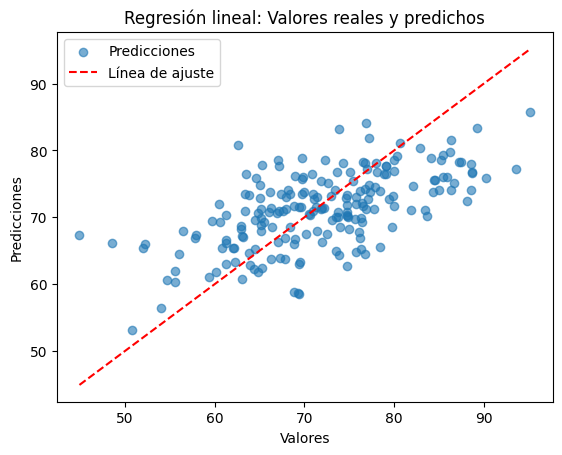

In [9]:
# Miramos con scatterplot
plt.scatter(y_test, y_pred, label='Predicciones', alpha= 0.6)

#Lineas de referencia

valor_min=min(y_test.min(), y_pred.min())
valor_max=max(y_test.max(),y_pred.max())
plt.plot([valor_min, valor_max], [valor_min, valor_max], color="red", linestyle="--", label="Línea de ajuste")

plt.xlabel("Valores")
plt.ylabel("Predicciones")
plt.title("Regresión lineal: Valores reales y predichos")
plt.legend()
plt.show()

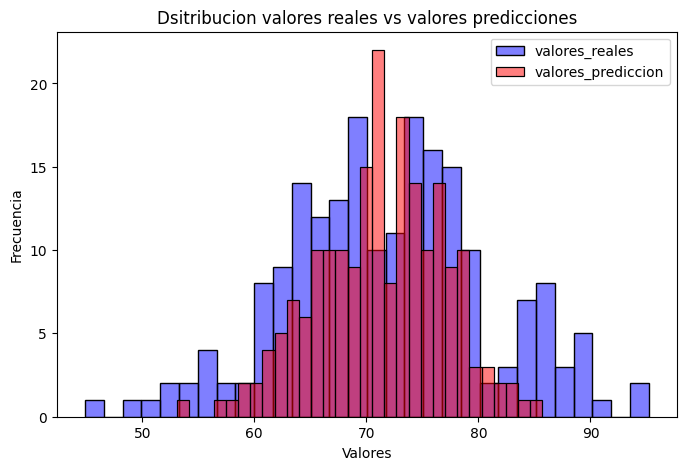

In [10]:
### Comparativa de distribuciones

plt.figure(figsize=(8,5))
n_bins=30

sns.histplot(y_test, bins= n_bins, edgecolor='black', color='blue', alpha= 0.5, label='valores_reales')
sns.histplot(y_pred, bins=n_bins, edgecolor='black', color='red', alpha=0.5, label='valores_prediccion')

plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.title('Dsitribucion valores reales vs valores predicciones')
plt.legend()
plt.show()

## Residuos

In [11]:
residuos= y_test - y_pred

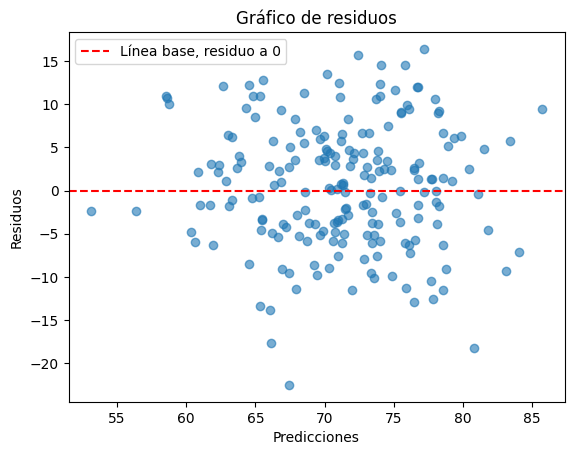

In [12]:
#Gráfico scatterplot

plt.scatter(y_pred, residuos, alpha= 0.6)
plt.axhline( y=0, color='red', linestyle='--', label='Línea base, residuo a 0')

plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfico de residuos')
plt.legend()
plt.show()

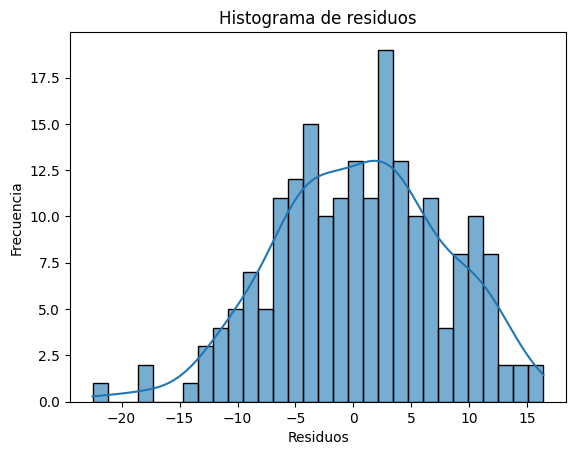

In [13]:
#Histograma

sns.histplot(residuos, bins=30, kde=True, edgecolor='black',alpha=0.6)

plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de residuos')
plt.show()

## Análisis de características

In [14]:
coef_estudiantes= pd.DataFrame({'Feature': X.columns.to_list(), 'Coefficient': modelo.coef_})

In [15]:
coef_estudiantes.sort_values(by='Coefficient',ascending=False, key=abs)

,Feature,Coefficient
0,horas_estudio_semanal,3.634885
1,nota_anterior,2.466054
2,tasa_asistencia,1.692361
3,nivel_dificultad,0.308370


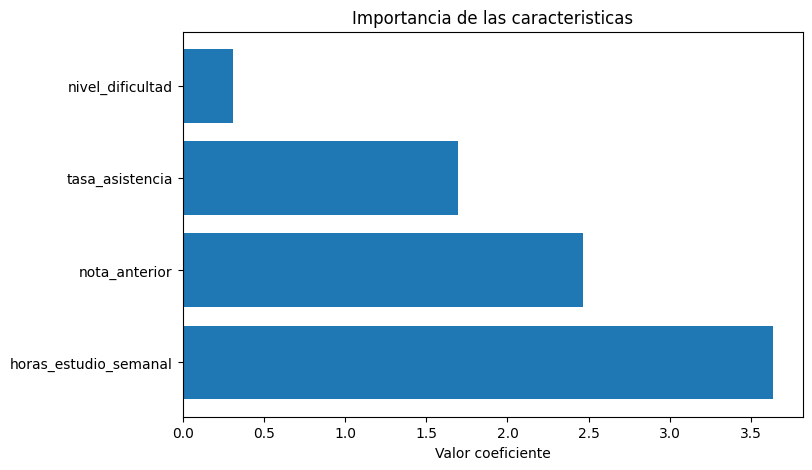

In [16]:
#Visualizarlos en gráfico

plt.figure(figsize=(8,5))
plt.barh(coef_estudiantes['Feature'], coef_estudiantes['Coefficient'])
plt.xlabel('Valor coeficiente')
plt.title('Importancia de las caracteristicas')
plt.show()

## Métricas

In [17]:
#Predicciones

y_train_pred= modelo.predict(X_train)
y_test_pred=modelo.predict(X_test)

In [18]:
#Evaluamos el modelo
metricas= {
    'train': {
        'R2': r2_score(y_train, y_train_pred),
        'MAE': mean_absolute_error(y_train, y_train_pred),
        'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        },

    'test': {
        'R2': r2_score(y_test, y_test_pred),
        'MAE': mean_absolute_error(y_test, y_test_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test,y_test_pred)),
    },
    }

estudiantes_metricas=pd.DataFrame(metricas).T

In [19]:
estudiantes_metricas.round(2)

# No explica muy bien los datos, R2 no cercano al 1. 

,R2,MAE,RMSE
train,0.37,6.08,7.67
test,0.37,5.85,7.19


Para mejorar el sistema de correlaciones, nos quedamos solo con las variables que mayor coeficientee importancia tienen para el modelo, eliminando el resto y aprobado, al estar relacionada directamente con la nota.

In [20]:
estudiantes_coeficientes_importantes= ['nota_anterior', 'horas_estudio_semanal', 'tasa_asistencia']

X = estudiantes[estudiantes_coeficientes_importantes]
y = estudiantes['nota_final']

Calculamos las metricas de este modelo reducido